# Random Forest Classifier for Study Group Project

This notebook implements a Random Forest Classifier to analyze and predict student progression and enrollment outcomes. The project aims to evaluate the effectiveness of discounts in driving successful enrollments and completions, optimizing resource allocation for Study Group's scholarship strategies.

# 0) Setup: Importing Libraries and Loading Data

In this section, the necessary libraries for data analysis, preprocessing, and model implementation are imported. The dataset is then loaded to initiate the exploration and transformation process. This setup ensures that all dependencies are correctly configured for efficient data manipulation and model training.

## 0.1) Import Data & Libraries

In [ ]:
# Check and Install Required Libraries
import sys
import subprocess

# List of required libraries and their import names
required_libraries = {
    'pandas': 'pd',
    'numpy': 'np',
    'seaborn': 'sns',
    'scikit-learn': 'sklearn',
    'imblearn': 'imblearn',
    'category_encoders': 'ce',
    'matplotlib': 'plt'
}

# Function to check and install libraries
def check_and_install_libraries(libraries):
    for lib, alias in libraries.items():
        try:
            __import__(lib)
            print(f"✅ {lib} is already installed.")
        except ImportError:
            print(f"❌ {lib} not found. Installing...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", lib])

# Check and install missing libraries
check_and_install_libraries(required_libraries)

# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, r2_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import category_encoders as ce
from sklearn.inspection import partial_dependence

# Display confirmation
print("\n All required libraries have been successfully imported.")

✅ pandas is already installed.
✅ numpy is already installed.
✅ seaborn is already installed.
❌ scikit-learn not found. Installing...
✅ imblearn is already installed.
✅ category_encoders is already installed.
✅ matplotlib is already installed.

 All required libraries have been successfully imported.


In [ ]:
# Load the dataset with custom file path input
import pandas as pd

# Prompt the user to enter the file path
file_path = input("Please enter the file path for the dataset (e.g., C:/path/to/sg_studentdata_unlocked.csv): ")

# Load the dataset
try:
    data = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: The file path is incorrect or the file does not exist. Please check and try again.")
except Exception as e:
    print(f"An error occurred: {e}")

# Display the first few rows of the dataset to confirm successful loading
data.head()


Please enter the file path for the dataset (e.g., C:/path/to/sg_studentdata_unlocked.csv): /content/drive/MyDrive/LSE Accelerator Employer Project - Team 11   Study Group Project/1_Datasets/sg_studentdata_unlocked.csv
Dataset loaded successfully!


,Centre,Programme,Area,Region,Sub Region,Country,Branch URN,Group URN,Lead Source,Student ID,...,Confirmation Date,Arrived Date,Cancellation Date,Completed,Progressed,Registered,Tuition Fees,Net Value,Discount,Discount Type
0,Cardiff,Diploma,ANZ & N Asia,ANZ,Australia,Aus - VIC,A31552,A31552,Standard Agent Booking,2864317,...,NaN,NaN,2023-10-05,NaN,NaN,NaN,19500.0,19500.0,0.0,NaN
1,Cardiff,Diploma,ANZ & N Asia,Hong Kong,Hong Kong,Hong Kong,A15382,A29520,Standard Agent Booking,2853769,...,NaN,NaN,2024-03-01,NaN,NaN,NaN,20000.0,20000.0,0.0,NaN
2,Cardiff,Diploma,ANZ & N Asia,Hong Kong,Hong Kong,Hong Kong,A15382,A29520,Standard Agent Booking,2863293,...,NaN,NaN,2024-03-01,NaN,NaN,NaN,19500.0,19500.0,0.0,NaN
3,Cardiff,Diploma,ANZ & N Asia,Hong Kong,Hong Kong,Hong Kong,A7608,A7608,Standard Agent Booking,2854643,...,NaN,NaN,2023-08-30,NaN,NaN,NaN,19500.0,19500.0,0.0,NaN
4,Cardiff,Diploma,ANZ & N Asia,Hong Kong,Hong Kong,Hong Kong,D1107,D1107,Standard Agent Booking,2871048,...,NaN,NaN,2024-05-24,NaN,NaN,NaN,24850.0,24850.0,0.0,NaN


# 1) Data Preprocessing

The data preprocessing steps are designed to clean and structure the dataset for optimal performance.

- (1.1) Setup Status Flags stages in the Applications process categorizes students into different stages of the application process, allowing for detailed segmentation and targeted analysis (more on the statuses below)
- (1.2) Exclude rejected applicants reduces noise and improves model accuracy by filtering out irrelevant records,
- (1.3) Handle Multiple Bookings per Student which retains the most relevant records for each student.
- (1.4) Define Discount %, Has Discount, Time to Outcome involves engineering discount-related features, including calculating discount percentages and identifying students who received a discount.
- (1.5) Categorical variables are encoded using appropriate methods:
    - (1.5.1) One-Hot Encoding for Lead Source, Programme, Area, and Centre
    - (1.5.3) Impact Encoding is applied to variables like Nationality and Group URN to capture complex relationships. This comprehensive preprocessing pipeline sets the foundation for effective feature engineering and model training in subsequent sections.
    - (1.5.2) Nationality: PCA (Clusters) was initially implemented to group nationalities into clusters for more efficient feature representation. However, this approach was excluded from the final model version to streamline the code and enhance performance.

## 1.1 Setup Status Flags stages in the Applications process

This section defines and sets up status flags for each stage of the student application process, including:

- Applicant: Students who submitted an application but have not yet received an offer.
- Rejected Applicant: Students whose applications were rejected.
- Offered: Students who received an offer but did not confirm.
- Confirmed: Students who confirmed their offer by paying a deposit.
- Dropout: Students who started the course but did not complete it.
- Enrolled: Students who arrived at the institution to start the course.
- Completed (Fail or Pass): Students who finished the course and either failed or passed.
- Progressed: Students who progressed to university.
- Non-Progressed Graduate: Students who completed the course but did not progress.
- Registered: Students who registered at the university, generating revenue.
- Non-Registered Graduate: Students who completed and progressed but did not register.
- Cancelled: Students who canceled their application or dropped out before completion.

In [ ]:
# Status Flags
data['Applicant'] = (data['Application Date'].notna()) & (data['Offered Date'].isna())
data['Rejected Applicant'] = (data['Application Date'].notna()) & (data['Offered Date'].isna()) & (data['Cancellation Date'].notna())
data['Offered'] = data['Offered Date'].notna() & data['Confirmation Date'].isna()
data['Confirmed'] = data['Confirmation Date'].notna()
data['Dropout'] = (data['Arrived Date'].notna()) & (data['Completed'].isna()) & (data['Cancellation Date'].isna())
data['Enrolled'] = data['Arrived Date'].notna()
data['Completed_Fail'] = (data['Completed'] == 'Fail')
data['Completed_Pass'] = (data['Completed'] == 'Pass')
data['Progressed'] = (data['Progressed'] == 'Yes')
data['Non_Progressed_Graduate'] = (data['Completed'] == 'Pass') & (data['Progressed'] == 'No')
data['Registered'] = (data['Registered'] == 'Yes')
data['Non_Registered_Graduate'] = (data['Progressed'] == 'Yes') & (data['Registered'] == 'No')
data['Cancelled'] = data['Cancellation Date'].notna()

## 1.2) Exclude rejected applicants

In [ ]:
data = data[data['Rejected Applicant'] == False].reset_index(drop=True)

## 1.3) Handle Multiple Bookings per Student

In [ ]:
# Flag for students with multiple bookings
multiple_bookings = data.groupby('Student ID')['Booking ID'].count()
students_with_multiple_bookings = multiple_bookings[multiple_bookings > 1]
data['Multiple_Bookings_Flag'] = data['Student ID'].isin(students_with_multiple_bookings.index).astype(int)

# Aggregate total bookings per student
booking_features = data.groupby('Student ID').agg(total_bookings=('Booking ID', 'count')).reset_index()
data = pd.merge(data, booking_features, on='Student ID', how='left')

# Define a helper function to select the relevant booking per student
def select_relevant_booking(group):
    # Case 1: If there's a confirmed booking, keep that
    confirmed_booking = group[group['Confirmation Date'].notna()]
    if not confirmed_booking.empty:
        return confirmed_booking.iloc[0]  # Keep the first confirmed booking

    # Case 2: If no confirmed booking exists, keep the canceled booking
    canceled_booking = group[group['Cancellation Date'].notna()]
    if not canceled_booking.empty:
        return canceled_booking.iloc[0]  # Keep the first canceled booking

    # If neither condition applies, return the first booking (fallback)
    return group.iloc[0]

# Group by Student ID and apply the selection logic
data = data.groupby('Student ID').apply(select_relevant_booking).reset_index(drop=True)

<ipython-input-5-011d3609e6ee>:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby('Student ID').apply(select_relevant_booking).reset_index(drop=True)


## 1.4 Define Discount %, Has Discount, Time to Outcome


In [ ]:
# Feature: Discount as percentage of tuition
data['Discount_Percentage'] = data['Discount'] / data['Tuition Fees'] * 100

# Create a binary feature indicating whether a student received a discount
data['Has_Discount'] = (data['Discount'] > 0).astype(int)

# Convert date columns to datetime
data['Application Date'] = pd.to_datetime(data['Application Date'])
data['Offered Date'] = pd.to_datetime(data['Offered Date'])
data['Cancellation Date'] = pd.to_datetime(data['Cancellation Date'])

# Compute the time to outcome (Offered or Cancelled)
data['Time_To_Outcome'] = np.where(
    data['Offered Date'].notna(),  # If Offered Date exists
    (data['Offered Date'] - data['Application Date']).dt.days,
    (data['Cancellation Date'] - data['Application Date']).dt.days  # Otherwise use Cancellation Date
)

## 1.5) Encoding Categorical Variables

### 1.5.1) Lead Source, Programme, Area, Centre: One-Hot encoding

In [ ]:
# Create dummy variables without replacing original columns
dummies = pd.get_dummies(data[['Lead Source', 'Programme', 'Area', 'Centre']], drop_first=False)

# Concatenate original DataFrame with the new dummy columns
data = pd.concat([data, dummies], axis=1)

#### 1.5.2) Nationality: PCA (Clusters)

These features were tested in early versions of the model. They are not used in *the* final version of the model so they appear as markdown to improve the efficiency of the code

```
# One-hot encode Nationality
encoder = OneHotEncoder(sparse_output=False, drop='first')
nationality_onehot = encoder.fit_transform(data[['Nationality']])

# Convert to a DataFrame for easy tracking of columns
nationality_onehot_df = pd.DataFrame(nationality_onehot, columns=encoder.get_feature_names_out(['Nationality']))

pca = PCA(n_components=5)  # Adjust the number of components as needed
nationality_pca = pca.fit_transform(nationality_onehot_df)

# Convert PCA components into a DataFrame
pca_columns = [f'Nationality_PCA_{i}' for i in range(nationality_pca.shape[1])]
nationality_pca_df = pd.DataFrame(nationality_pca, columns=pca_columns)

# Add the PCA components back to the original dataset
data = pd.concat([data.reset_index(drop=True), nationality_pca_df.reset_index(drop=True)], axis=1)

# Get the contribution of each original nationality to the PCA components
pca_loading = pd.DataFrame(pca.components_, columns=nationality_onehot_df.columns)

# Find the top contributing nationalities for each PCA component
for i in range(pca_loading.shape[0]):
    print(f"\nTop contributing nationalities to Nationality_PCA_{i}:")
    print(pca_loading.loc[i].nlargest(5))

```


```
Top contributing nationalities to Nationality_PCA_0:
Nationality_Chinese       0.932079
Nationality_Danish       -0.000025
Nationality_Belizean     -0.000025
Nationality_Bhutanese    -0.000025
Nationality_Belarusian   -0.000025
Name: 0, dtype: float64

Top contributing nationalities to Nationality_PCA_1:
Nationality_Pakistani     0.805169
Nationality_Chinese       0.058898
Nationality_Malian       -0.000008
Nationality_St. Lucian   -0.000008
Nationality_Paraguayan   -0.000008
Name: 1, dtype: float64

Top contributing nationalities to Nationality_PCA_2:
Nationality_Indian               0.747145
Nationality_Kuwaiti              0.050708
Nationality_Egyptian             0.023088
Nationality_Qatari               0.012711
Nationality_Hong Kong Chinese    0.011696
Name: 2, dtype: float64

Top contributing nationalities to Nationality_PCA_3:
Nationality_Kuwaiti              0.650198
Nationality_Egyptian             0.163503
Nationality_Qatari               0.077054
Nationality_Hong Kong Chinese    0.069918
Nationality_Nigerian             0.054860
Name: 3, dtype: float64

Top contributing nationalities to Nationality_PCA_4:
Nationality_Kuwaiti      0.662237
Nationality_Indian       0.246524
Nationality_Saudi        0.223725
Nationality_Pakistani    0.208964
Nationality_Chinese      0.155511
Name: 4, dtype: float64

```



#### 1.5.3) Nationality, Area, Centre, Branch URN, Group URN: Impact Encoding (Enrollment)

In [ ]:
# Impact encode Nationality and Region using the target mean
data['Nationality_Impact'] = data.groupby('Nationality')['Enrolled'].transform('mean')
data['Area_Impact'] = data.groupby('Area')['Enrolled'].transform('mean')
data['Centre_Impact'] = data.groupby('Centre')['Enrolled'].transform('mean')
data['Branch_URN_Impact'] = data.groupby('Branch URN')['Enrolled'].transform('mean')
data['Group_URN_Impact'] = data.groupby('Branch URN')['Enrolled'].transform('mean')

# 2. Random Forest Classifier: Feature Engineering, Model Tuning, and Discount Impact Analysis  


Structure of the section:

2.1 **Feature Engineering**  
   - Selection of the features to be included in the model

2.2 **Hyperparameters Tuning**  
   - Grid Search with cross-validation for optimal Random Forest parameters (included as markdown to improve code efficiency)  

2.3 **Random Forest Model Training and Evaluation**  
   - Area-specific models with F1 Score, AUC, and Confusion Matrix  

2.4 **Feature Importance Analysis**  
- **2.4.1 Bar Chart Across Areas, Grouped by Feature**  
- **2.4.2 Table Overview**  
- **2.4.3 Pie Chart, Per Area**  
- **2.4.4 Stacked Bar Chart Per Area**  
- **2.4.5 Export to CSV for External Visualization**  

2.5 **Discount Analysis (PDP Plots, Area Level and Agent Level)**  
- **2.5.1 Enrollment Probability & Discount, Across Areas (Single View)**  
- **2.5.2 Enrollment Probability & Discount, Across Areas (Diminishing Marginal Returns Area)**  
- **2.5.3 Enrollment Probability & Discount, Across Areas (Facet View)**  
- **2.5.4 Enrollment Probability & Discount, Agents Level Analysis (GROUP URN)**  
- **2.5.5 Enrollment Probability & Discount Tiers**  
  - **2.5.5.1 Bar Chart Per Tier**  
  - **2.5.5.2 Line Chart Per Tier Grouped by Area**


## Business Context:
This model-driven approach optimizes scholarship allocation for Study Group by:
- Tailoring discount strategies to maximize enrollments and ROI.
- Providing regional and agent-level insights for targeted marketing.
- Identifying underperforming discounts and agents to minimize missed opportunities.



## Methodologies and Libraries:
This analysis utilizes **Random Forest Classifiers** from `sklearn.ensemble` due to their robustness with non-linear interactions and feature importance interpretability. **Grid Search with Cross-Validation** (`sklearn.model_selection.GridSearchCV`) optimizes model parameters, ensuring regional adaptability. **Partial Dependence Plots** (`sklearn.inspection`) offer actionable insights into discount effectiveness. Visualizations are crafted using **Matplotlib** and **Seaborn**, highlighting feature importances and enrollment trends.

## 2.1 Feature Engineering

In [ ]:
features = ['Discount',
            'Net Value',
            'Nationality_Impact',
            'Centre_Impact',
            'Group_URN_Impact'
            ]

 ## 2.2) Hyperparameters tuning

```
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib  # To save the best parameters


#Custom threshold
threshold = 0.4

#Define exhaustive Grid Search parameter grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', {0: 1, 1: 3}]
}


area_models = {}
best_params_per_area = {}

for area in data['Area'].unique():
    print(f"\n Running **Grid Search** for Area: {area}...")

    # Extract area-specific data
    area_data = data[data['Area'] == area]
    X_area = area_data[features]
    y_area = area_data['Enrolled'].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(X_area, y_area, test_size=0.2, random_state=42)

    # Use a subset of data for quicker tuning (optional)
    X_train_sample = X_train.sample(frac=0.3, random_state=42)
    y_train_sample = y_train.loc[X_train_sample.index]

    # Run **Grid Search** (exhaustive)
    grid_search = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid,
        scoring='f1',
        cv=3,  # More folds for better performance evaluation
        n_jobs=-1
    )
    grid_search.fit(X_train_sample, y_train_sample)

    # Get best parameters and save them
    best_params = grid_search.best_params_
    best_params_per_area[area] = best_params
    print(f" Best parameters for {area}: {best_params}")

```




## 2.3) Random Forest Model Training and Evaluation


🔵 Training Final Model for Area: ANZ & N Asia...

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       219
           1       0.75      0.78      0.76        80

    accuracy                           0.87       299
   macro avg       0.83      0.84      0.84       299
weighted avg       0.87      0.87      0.87       299

AUC Score: 0.9080


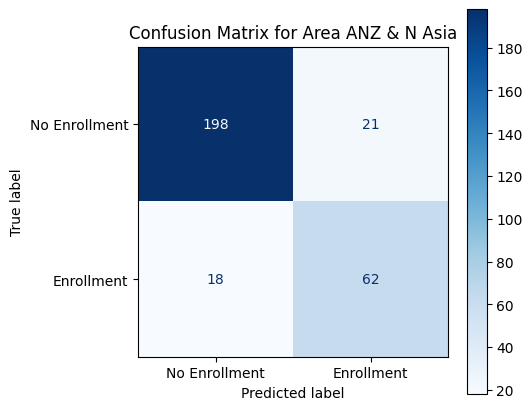


🔵 Training Final Model for Area: UK EU & Americas...

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1303
           1       0.78      0.62      0.69       136

    accuracy                           0.95      1439
   macro avg       0.87      0.80      0.83      1439
weighted avg       0.94      0.95      0.95      1439

AUC Score: 0.9168


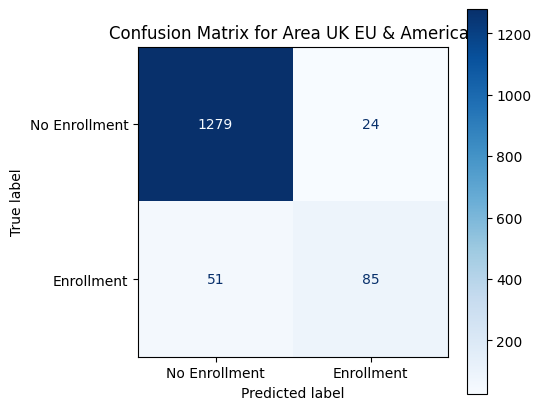


🔵 Training Final Model for Area: South Asia...

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       663
           1       0.72      0.64      0.68        61

    accuracy                           0.95       724
   macro avg       0.84      0.81      0.83       724
weighted avg       0.95      0.95      0.95       724

AUC Score: 0.9505


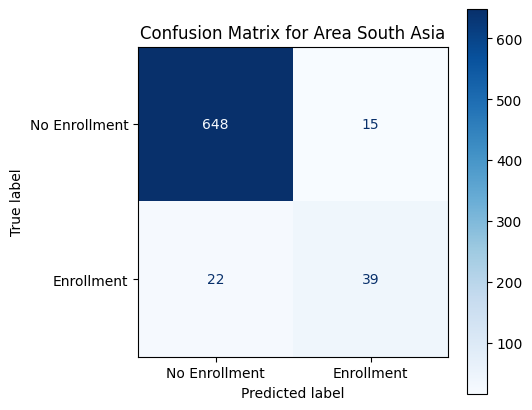


🔵 Training Final Model for Area: China...

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      1111
           1       0.76      0.87      0.81       267

    accuracy                           0.92      1378
   macro avg       0.86      0.90      0.88      1378
weighted avg       0.93      0.92      0.92      1378

AUC Score: 0.9632


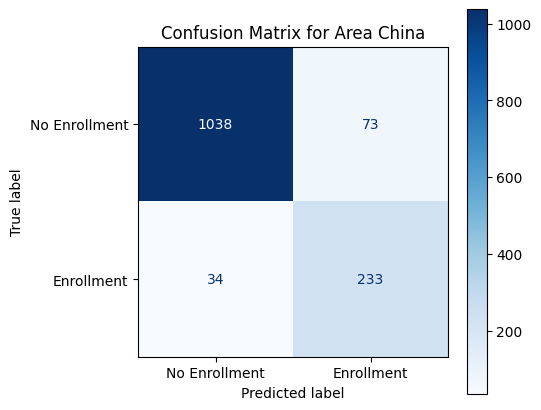


🔵 Training Final Model for Area: ELMEA & Pakistan...

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      1648
           1       0.68      0.69      0.68       237

    accuracy                           0.92      1885
   macro avg       0.82      0.82      0.82      1885
weighted avg       0.92      0.92      0.92      1885

AUC Score: 0.9257


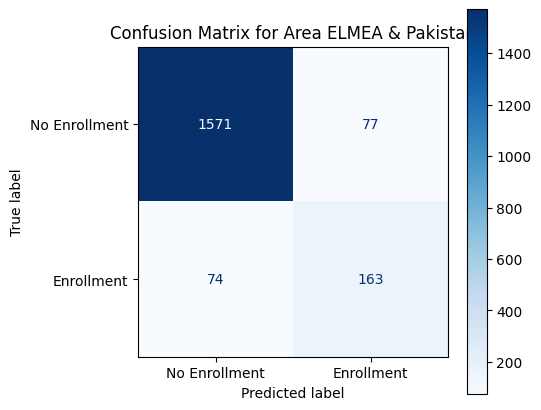


🔵 Training Final Model for Area: SE Asia...

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       144
           1       0.82      0.89      0.86        57

    accuracy                           0.92       201
   macro avg       0.89      0.91      0.90       201
weighted avg       0.92      0.92      0.92       201

AUC Score: 0.9561


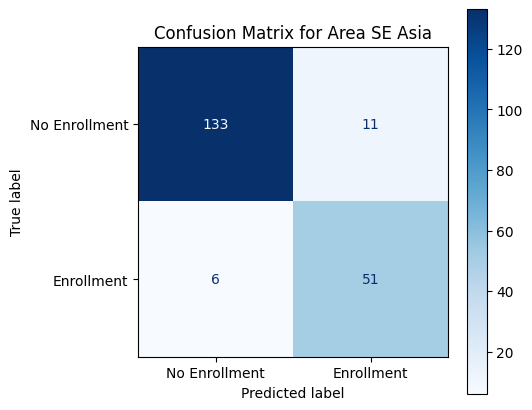

In [ ]:
# Custom threshold
threshold = 0.4

# Manually entered best parameters from Grid Search (modify as needed)
best_params_per_area = {
    "ANZ & N Asia": {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100},
    "UK EU & Americas": {'class_weight': {0: 1, 1: 3}, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300},
    "South Asia": {'class_weight': {0: 1, 1: 3}, 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100},
    "China": {'class_weight': {0: 1, 1: 3}, 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100},
    "ELMEA & Pakistan": {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 15, 'class_weight': {0: 1, 1: 3}},
    "SE Asia": {'class_weight': {0: 1, 1: 3}, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
}

area_models = {}

for area in data['Area'].unique():
    print(f"\n🔵 Training Final Model for Area: {area}...")

    # Extract area-specific data
    area_data = data[data['Area'] == area]
    X_area = area_data[features]
    y_area = area_data['Enrolled'].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(X_area, y_area, test_size=0.2, random_state=42)

    # Use the manually entered best parameters for this area
    best_params = best_params_per_area.get(area, {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'class_weight': 'balanced'})

    # Train the final model
    clf = RandomForestClassifier(**best_params, random_state=42)
    clf.fit(X_train, y_train)

    # Store trained model
    area_models[area] = clf

    # Evaluate the model
    y_prob = clf.predict_proba(X_test)[:, 1]
    y_pred_custom = (y_prob >= threshold).astype(int)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_custom))
    print(f"AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_custom)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Enrollment", "Enrollment"])

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    plt.title(f'Confusion Matrix for Area {area}')
    plt.show()


## Results: Model Training and Evaluation

The **Random Forest Classifier** demonstrates varied performance across the different regions, achieving an **acceptable level of accuracy** that supports strategic decision-making. Although the models are not optimized to the highest accuracy standards, **feature engineering** and **hyperparameter tuning** have significantly enhanced their effectiveness, revealing important insights into regional enrollment patterns.

### Key Observations:
- **ANZ & N Asia:** Achieved a balanced performance with an **F1-score of 0.76** for the positive class and an **AUC score of 0.9080**, reflecting good discriminatory power.
- **UK EU & Americas:** Exhibited high precision but lower recall for the positive class, resulting in an **F1-score of 0.69** and an **AUC score of 0.9168**. The model tends to be more conservative, favoring precision over recall.
- **South Asia:** Demonstrated strong overall accuracy with an **AUC score of 0.9505**, although the positive class recall is comparatively lower, impacting the F1-score.
- **China:** Achieved robust performance with a **balanced F1-score of 0.81** and a high **AUC score of 0.9632**, indicating effective classification for this region.
- **ELMEA & Pakistan:** Displayed good precision but moderate recall for the positive class, resulting in an **F1-score of 0.68** and an **AUC score of 0.9257**.
- **SE Asia:** Delivered consistent and reliable results with an **F1-score of 0.86** and an **AUC score of 0.9561**, confirming its effectiveness in this region.

### Performance Considerations:
- The models demonstrate **acceptable but not exceptional** accuracy across regions, with variations largely attributable to regional differences in enrollment patterns and discount sensitivity.
- **Precision and recall trade-offs** are evident, with certain models emphasizing precision over recall, impacting the F1-score in regions such as **UK EU & Americas** and **ELMEA & Pakistan**.
- Consistently high **AUC scores** across all regions confirm the models' strong discriminatory power despite differences in class balance and recall rates.

### Strategic Implications:
- The results indicate that while model performance varies, they provide **valuable strategic insights** into discount effectiveness and enrollment behavior, supporting data-driven decision-making.
- **Region-specific variations** reinforce the decision to train separate models for each area, ensuring targeted and actionable insights.
- These findings enable **informed discount allocation strategies**, helping to optimize resource utilization and enhance enrollment outcomes.

### Conclusion:
Overall, the models demonstrate a **sound balance between interpretability and performance**, making them robust tools for strategic decision-making. The insights derived contribute to more effective scholarship allocation strategies, supporting Study Group's objective of maximizing enrollment while minimizing missed opportunities.


## 2.4) Feature Importance Analysis

### 2.4.1) Bar chart across areas, grouped by feature

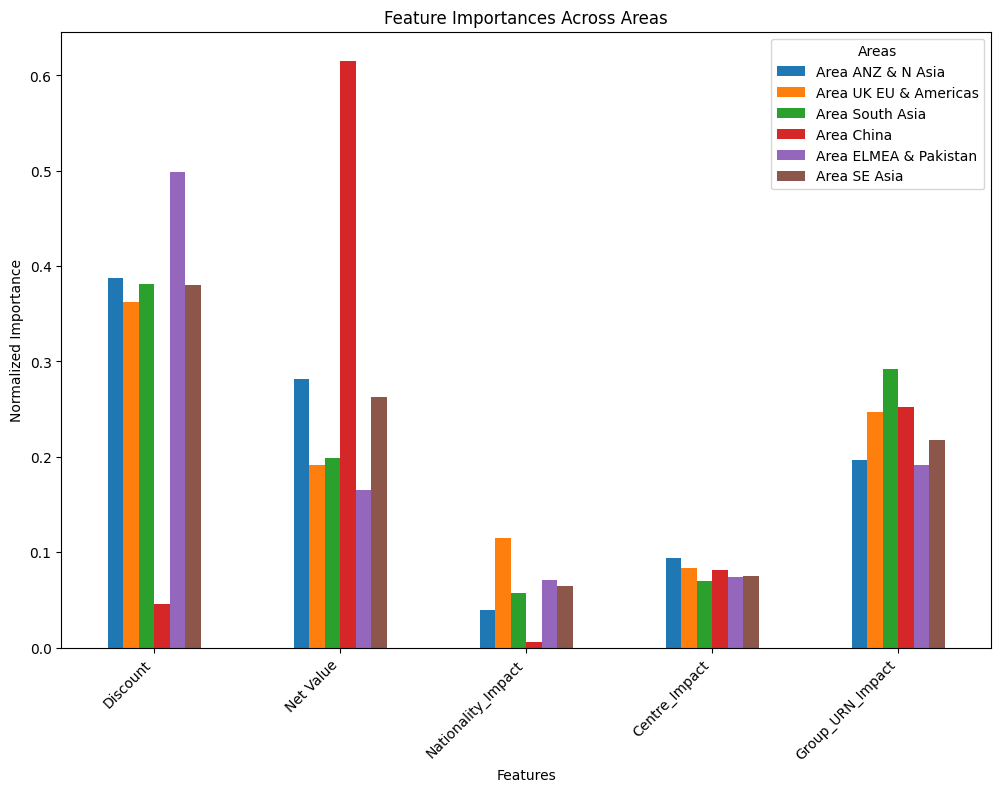

In [ ]:
# Initialize a DataFrame to store feature importances for each area
feature_importance_df = pd.DataFrame()

# Collect feature importances from each area's model
for area in area_models.keys():
    clf = area_models[area]  # Get the trained model for the area

    # Create a DataFrame of feature importances for this area
    area_feature_importance = pd.DataFrame({
        'Feature': features,
        f'Area {area}': clf.feature_importances_ / clf.feature_importances_.sum()  # Normalize feature importances
    })

    # Merge feature importance data correctly
    if feature_importance_df.empty:
        feature_importance_df = area_feature_importance
    else:
        feature_importance_df = feature_importance_df.merge(area_feature_importance, on='Feature')

# Plot the feature importances for all areas
feature_importance_df.set_index('Feature', inplace=True)
feature_importance_df.plot(kind='bar', figsize=(12, 8))

plt.title('Feature Importances Across Areas')
plt.ylabel('Normalized Importance')
plt.xlabel('Features')
plt.legend(title='Areas')
plt.xticks(rotation=45, ha='right')
plt.show()


### 2.4.2) Table Overview

In [ ]:
feature_importance_df

,Area ANZ & N Asia,Area UK EU & Americas,Area South Asia,Area China,Area ELMEA & Pakistan,Area SE Asia
Feature,,,,,,
Discount,0.387389,0.362796,0.381338,0.045300,0.498159,0.380074
Net Value,0.282155,0.191219,0.198996,0.615089,0.165634,0.263010
Nationality_Impact,0.039153,0.115094,0.057028,0.005695,0.071172,0.064870
Centre_Impact,0.094082,0.083639,0.069989,0.081879,0.073760,0.074682
Group_URN_Impact,0.197221,0.247253,0.292650,0.252037,0.191274,0.217364


### 2.4.3) Pie chart, per area

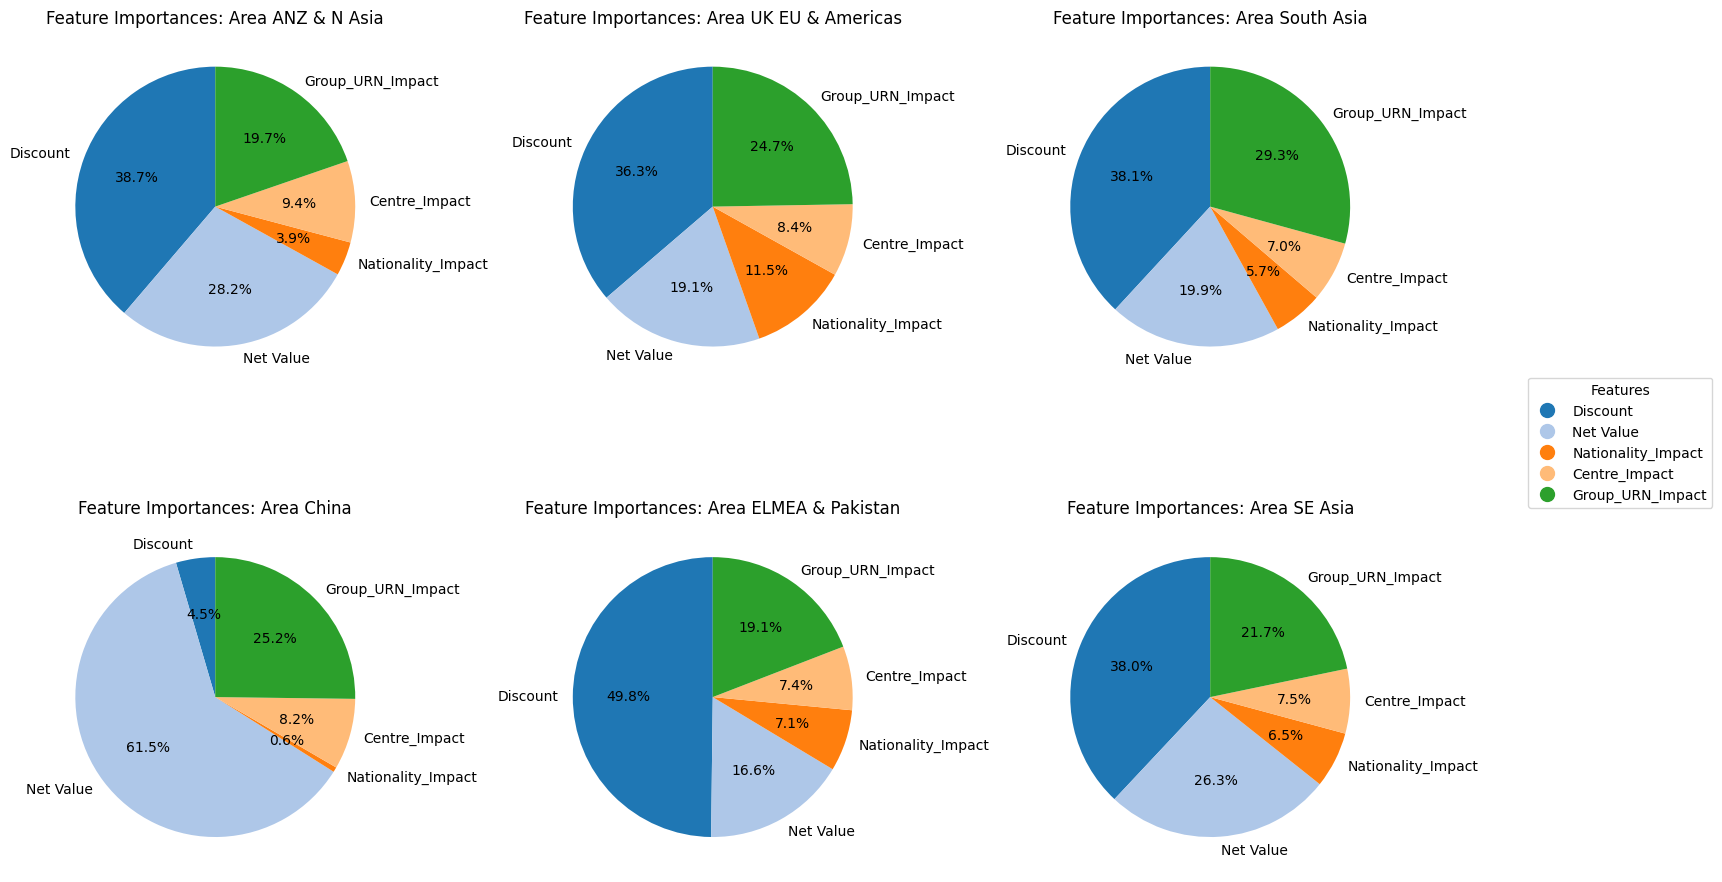

In [ ]:
# Initialize a DataFrame to store feature importances for each area
feature_importance_df = pd.DataFrame()

# Collect feature importances from each area's model
for area in area_models.keys():
    clf = area_models[area]  # Get the trained model for the area

    # Create a DataFrame of feature importances for this area
    area_feature_importance = pd.DataFrame({
        'Feature': features,
        f'Area {area}': clf.feature_importances_ / clf.feature_importances_.sum()  # Normalize feature importances
    })

    # Merge feature importance data correctly
    if feature_importance_df.empty:
        feature_importance_df = area_feature_importance
    else:
        feature_importance_df = feature_importance_df.merge(area_feature_importance, on='Feature')

# Set the feature column as the index for easier access
feature_importance_df.set_index('Feature', inplace=True)

# Define a color map for consistent feature coloring
colors = plt.cm.tab20.colors  # Use a colormap with many distinct colors
feature_colors = {feature: colors[i % len(colors)] for i, feature in enumerate(feature_importance_df.index)}

# Plot configuration: 2 rows, 3 columns for 6 pie charts
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing

# Iterate through each area and plot the pie chart
for i, area in enumerate(feature_importance_df.columns):
    # Data for the pie chart
    feature_importances = feature_importance_df[area]
    features = feature_importances.index

    # Plot pie chart with consistent feature colors
    axes[i].pie(
        feature_importances,
        labels=features,
        autopct='%1.1f%%',
        startangle=90,
        colors=[feature_colors[feature] for feature in features]
    )
    axes[i].set_title(f'Feature Importances: {area}')

# Add a shared legend
fig.legend(
    handles=[plt.Line2D([0], [0], marker='o', color=feature_colors[feature], linestyle='', markersize=10) for feature in feature_colors],
    labels=feature_colors.keys(),
    title='Features',
    loc='center right',
    bbox_to_anchor=(1.15, 0.5)
)

# Adjust layout and spacing
plt.tight_layout()
plt.show()


### 2.4.4) Stacked bar chart per area

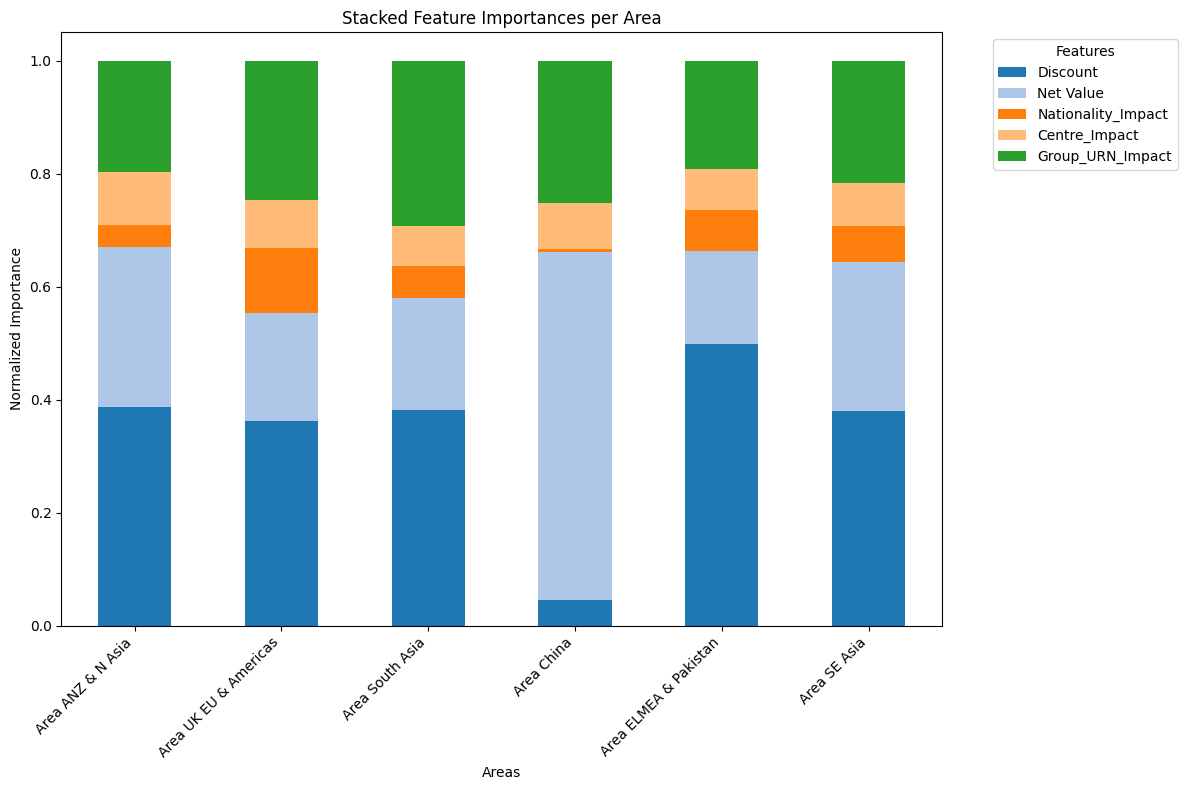

In [ ]:

# Initialize a DataFrame to store feature importances for each area
feature_importance_df = pd.DataFrame()

# Collect feature importances from each area's model
for area in area_models.keys():
    clf = area_models[area]  # Get the trained model for the area

    # Create a DataFrame of feature importances for this area
    area_feature_importance = pd.DataFrame({
        'Feature': features,
        f'Area {area}': clf.feature_importances_ / clf.feature_importances_.sum()  # Normalize feature importances
    })

    # Merge feature importance data correctly
    if feature_importance_df.empty:
        feature_importance_df = area_feature_importance
    else:
        feature_importance_df = feature_importance_df.merge(area_feature_importance, on='Feature')

# Set 'Feature' as the index and transpose the DataFrame
stacked_df = feature_importance_df.set_index('Feature').T

# Define a color map for consistent feature coloring
colors = plt.cm.tab20.colors  # Use the 'tab20' colormap
feature_colors = {feature: colors[i % len(colors)] for i, feature in enumerate(stacked_df.columns)}

# Plot the stacked bar chart
stacked_df.plot(kind='bar', stacked=True, figsize=(12, 8), color=[feature_colors[feature] for feature in stacked_df.columns])

# Chart details
plt.title('Stacked Feature Importances per Area')
plt.ylabel('Normalized Importance')
plt.xlabel('Areas')
plt.legend(title='Features', bbox_to_anchor=(1.05, 1), loc='upper left')  # Legend outside the chart
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###      2.4.5) Export the feature importances to a CSV file for data visualisation outside the notebook
feature_importance_df.to_csv('feature_importances_per_area.csv', index=False)

## Feature Importance Analysis: Key Insights

This section presents the relative importance of various features in predicting enrollment outcomes across different regions. The results provide valuable insights into the factors that influence student decision-making, highlighting both common patterns and region-specific variations.

### Key Findings:
- **China:**  
  - **Net Tuition After Discount** is the most influential factor, indicating that financial considerations heavily impact enrollment decisions in this market. See section 3 for more on China
  
- **Other regions:**  
  - Enrollment outcomes are influenced by a more **balanced set of features**, suggesting that no single factor dominates the decision-making process. Instead, a combination of financial, demographic, and agent-specific influences shape student behavior in this region.

- **Agent-Level Variation:**  
  - The integration of **variation across agents** as a feature revealed its significant contribution to enrollment predictions, ranging between **19-29%** across regions.
  - Notably, **South Asia** is the most affected by agent-level differences, highlighting the critical role of agent networks and localized marketing strategies in influencing enrollment decisions.

- **Pakistan (ELMEA & Pakistan):**  
  - **Discounts** emerged as the most impactful factor, reinforcing the importance of **financial incentives** in driving enrollment in this market. This suggests that targeted scholarship strategies could be particularly effective in this region.

### Strategic Implications:
These insights enable more **targeted discount strategies** by region, ensuring optimal resource allocation and maximizing enrollment outcomes. The findings also highlight the need for tailored **agent engagement strategies**, particularly in South Asia, to capitalize on agent-driven market dynamics.

Overall, the feature importance analysis provides a nuanced understanding of the factors influencing student enrollment, supporting **data-driven decision-making** for effective scholarship allocation.


## 2.5) Discount Analysis (PDP Plots, Area Level and Agent Level)

### 2.5.1) **Erollment** Probability & Discount, Across Areas (Single View):

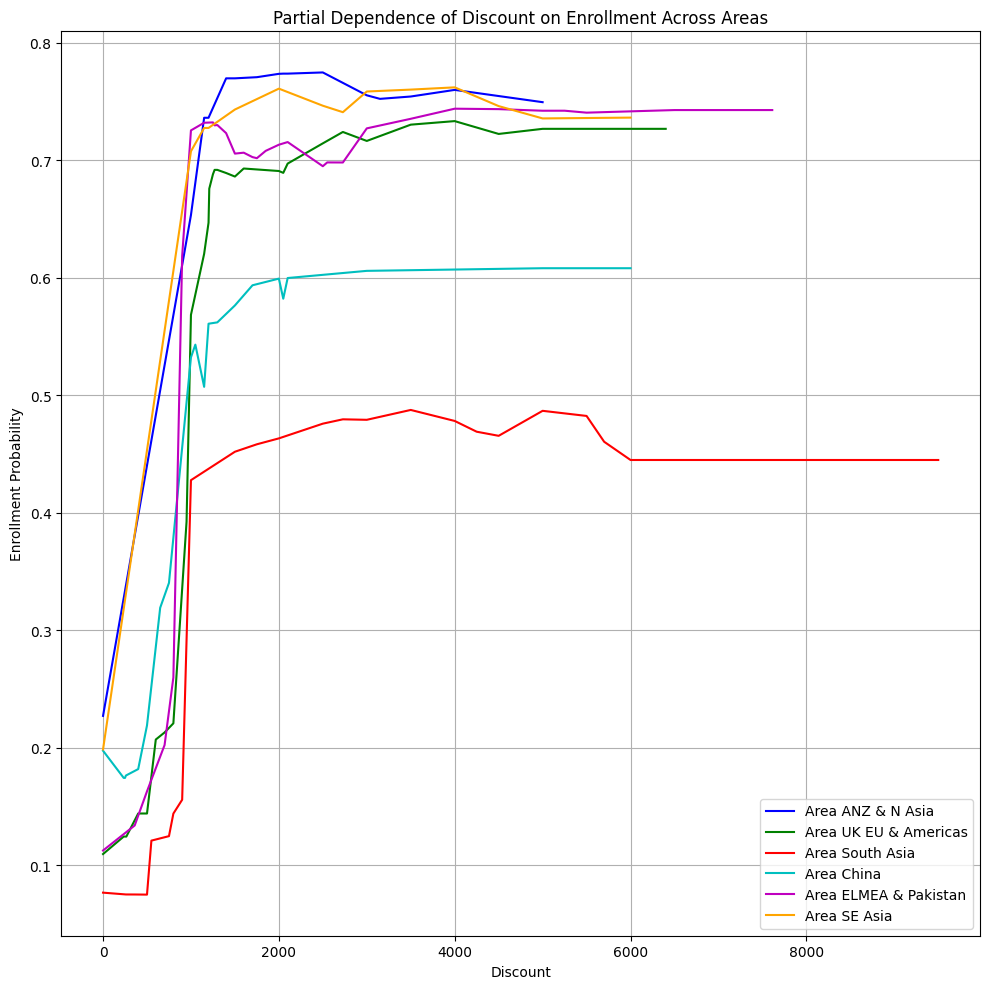

In [ ]:
# Initialize the plot
plt.figure(figsize=(10, 10))
colors = ['b', 'g', 'r', 'c', 'm', 'orange']  # Different colors for each area

# Initialize a DataFrame to store PDP data for export
pdp_data_list = []

# Plot PDP for each area using trained models
for i, area in enumerate(area_models.keys()):

    # Filter area-specific data
    area_data = data[data['Area'] == area]
    X_area = area_data[features]

    # Use the trained model for the current area
    clf = area_models[area]

    # Calculate partial dependence for the discount feature
    pdp_results = partial_dependence(clf, X_area, [X_area.columns.get_loc('Discount')])
    pdp_values = pdp_results['average'][0]  # Average predicted response
    discount_values = pdp_results['grid_values'][0]  # Corresponding discount values

    # Store the PDP data for export
    pdp_data = pd.DataFrame({
        'Discount': discount_values,
        'Enrollment_Probability': pdp_values,
        'Area': f'Area {area}'
    })
    pdp_data_list.append(pdp_data)

    # Plot the PDP
    plt.plot(discount_values, pdp_values, label=f'Area {area}', color=colors[i % len(colors)])

# Combine and export all PDP data to CSV
pdp_full_data = pd.concat(pdp_data_list, ignore_index=True)
pdp_full_data.to_csv('pdp_discount_per_area.csv', index=False)

# Finalize plot
plt.xlabel('Discount')
plt.ylabel('Enrollment Probability')
plt.title('Partial Dependence of Discount on Enrollment Across Areas')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 2.5.2) Enrollment Probability & Discount, Across Areas (Single View, Diminishing Marginal Returns Area)

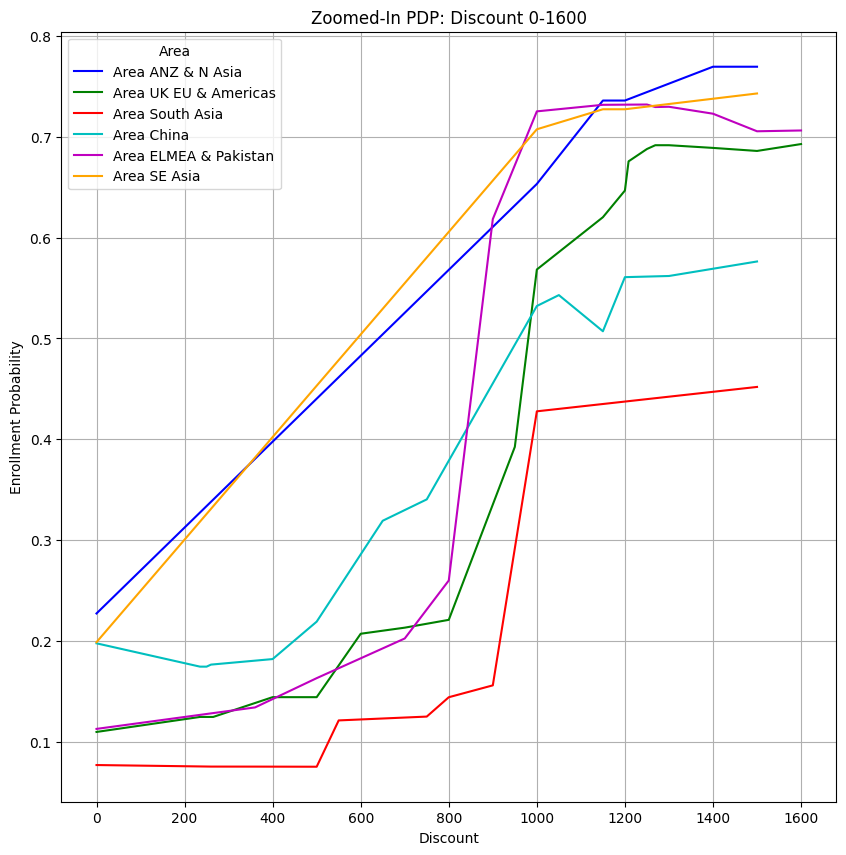

In [ ]:
# Zoomed-In PDP Plot (Discount: 0-1600, Enrollment Probability > 0)
plt.figure(figsize=(10, 10))

# Filter data for the zoomed-in region
pdp_zoomed = pdp_full_data[
    (pdp_full_data["Discount"] >= 0) &
    (pdp_full_data["Discount"] <= 1600) &
    (pdp_full_data["Enrollment_Probability"] > 0)
]

# Plot each area separately in the zoomed-in graph
sns.lineplot(
    data=pdp_zoomed,
    x="Discount",
    y="Enrollment_Probability",
    hue="Area",
    palette=colors[: len(area_models.keys())]  # Use the same colors
)

plt.xlabel("Discount")
plt.ylabel("Enrollment Probability")
plt.title("Zoomed-In PDP: Discount 0-1600")
plt.legend(title="Area")
plt.grid(True)
plt.show()

### 2.5.3) Enrollment Probability & Discount, Across Areas, Facet View)

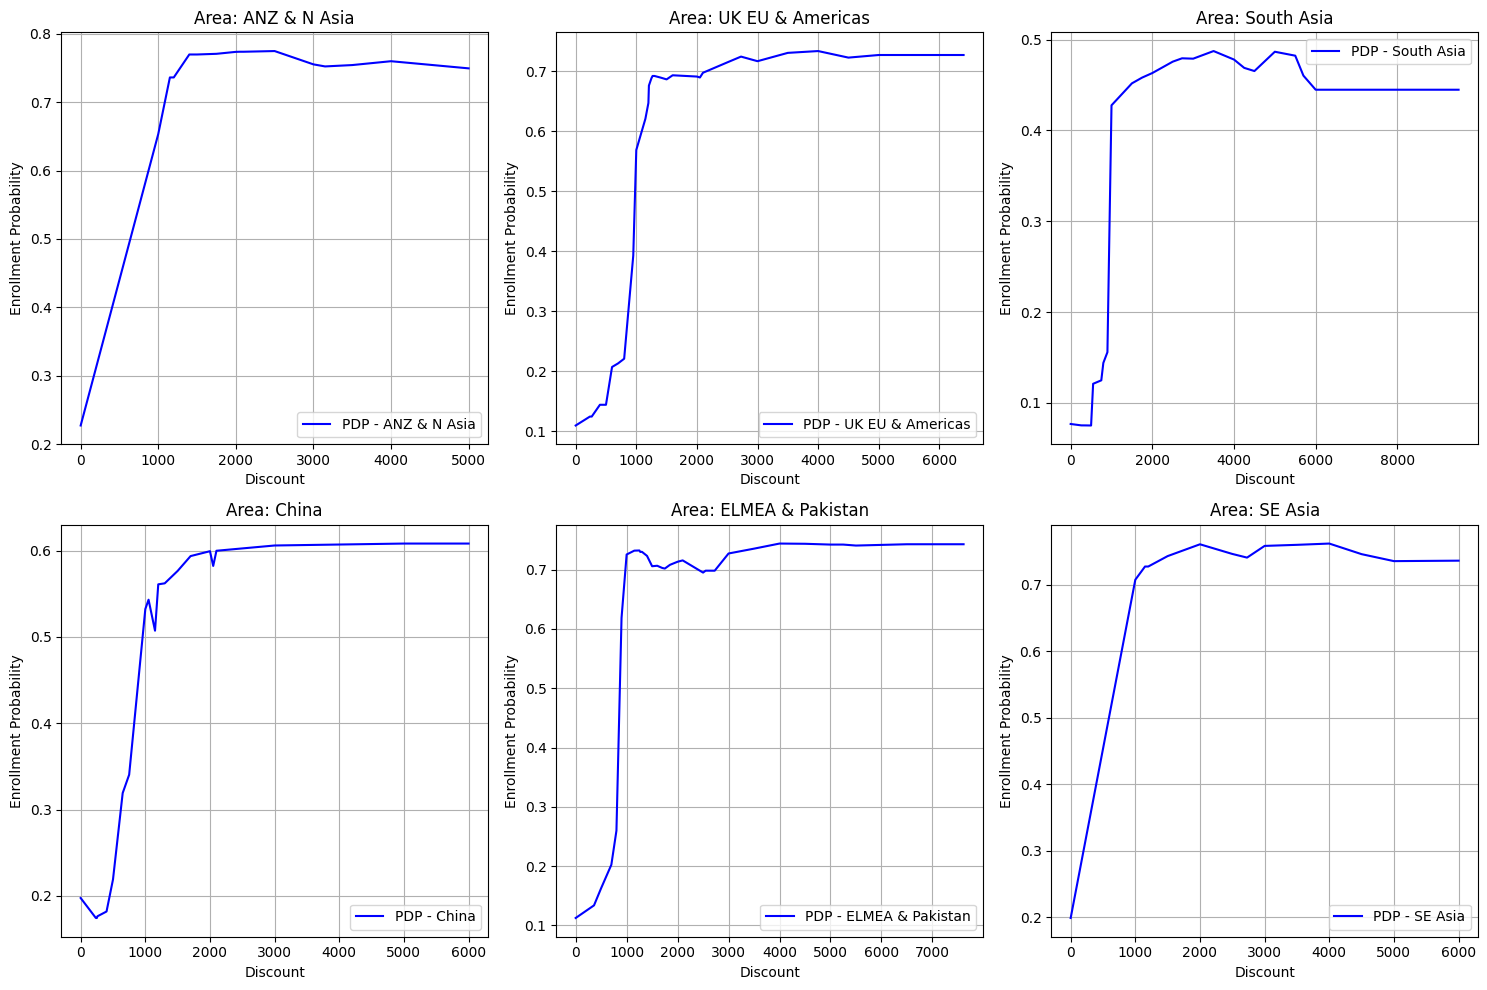

In [ ]:
# Initialize PDP storage
pdp_data_list = []

# Create subplots with one chart per area
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))  # Adjust grid layout based on # of areas
axes = axes.flatten()

# Plot PDP for each area in separate subplots
for i, (area, ax) in enumerate(zip(area_models.keys(), axes)):

    # Filter area-specific data
    area_data = data[data['Area'] == area]
    X_area = area_data[features]

    # Use the trained model for the current area
    clf = area_models[area]

    # Calculate PDP
    pdp_results = partial_dependence(clf, X_area, [X_area.columns.get_loc('Discount')])
    pdp_values = pdp_results['average'][0]  # Average predicted response
    discount_values = pdp_results['grid_values'][0]  # Corresponding discount values

    # Store PDP data for export
    pdp_data = pd.DataFrame({'Discount': discount_values, 'Enrollment_Probability': pdp_values, 'Area': area})
    pdp_data_list.append(pdp_data)

    # Plot PDP for this area in its own subplot
    ax.plot(discount_values, pdp_values, label=f'PDP - {area}', color='b')
    ax.set_title(f'Area: {area}')
    ax.set_xlabel('Discount')
    ax.set_ylabel('Enrollment Probability')
    ax.grid(True)
    ax.legend()

# Export PDP data to CSV
pdp_full_data = pd.concat(pdp_data_list, ignore_index=True)
pdp_full_data.to_csv('pdp_discount_per_area.csv', index=False)

# Adjust layout and show plots
plt.tight_layout()
plt.show()

### 2.5.4) Enrollment Probability & Discount, Agents Level Analysis (GROUP URN)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display
from sklearn.inspection import partial_dependence

# 🔹 Step 1: Define the Interactive Widgets
available_areas = data["Area"].unique()

# Sort Group URNs for each area
area_group_mapping = {
    area: sorted(data[data["Area"] == area]["Group URN"].unique().tolist())  # Sorting alphabetically
    for area in available_areas
}

# Area selection dropdown
area_selector = widgets.Dropdown(
    options=available_areas,
    description="Select Area:",
    style={"description_width": "initial"},
)

# Group URN search-enabled dropdown
group_urn_selector = widgets.Combobox(
    options=area_group_mapping[available_areas[0]],  # Default to first area
    description="Select Group URN:",
    placeholder="Type to search...",
    ensure_option=True,  # Ensures only valid options can be selected
    style={"description_width": "initial"},
)

# 🔹 Step 2: Update Group URN Dropdown When Area Changes
def update_group_urn_options(*args):
    group_urn_selector.options = sorted(area_group_mapping[area_selector.value])  # Keep sorted order

area_selector.observe(update_group_urn_options, "value")

def generate_pdp(area, group_urn):
    print(f"🔵 Running PDP for Area: {area}, Group URN: {group_urn}")

    # Fetch the correct trained model for the selected area
    clf = area_models[area]
    trained_features = clf.feature_names_in_

    # 🔹 Step 1: Compute PDP for Selected Group URN
    X_sample_group = data[data["Area"] == area][trained_features].sample(frac=0.1, random_state=42)

    selected_group_impact = data.loc[data["Group URN"] == group_urn, "Group_URN_Impact"].iloc[0]

    # Set Group URN Impact to the selected group's value
    X_temp_group = X_sample_group.copy()
    X_temp_group["Group_URN_Impact"] = selected_group_impact

    # Fill missing features
    missing_features = set(trained_features) - set(X_temp_group.columns)
    for feature in missing_features:
        X_temp_group[feature] = 0
    X_temp_group = X_temp_group[trained_features]

    pdp_results_group = partial_dependence(clf, X_temp_group, [X_temp_group.columns.get_loc("Discount")])
    discount_values = pdp_results_group["grid_values"][0]
    enrollment_probabilities_group = pdp_results_group["average"][0]

    # 🔹 Step 2: Compute **True Area-Level PDP** (Ignoring Group URN Filtering)
    X_sample_area = data[data["Area"] == area][trained_features].sample(frac=0.1, random_state=42)

    pdp_results_area = partial_dependence(clf, X_sample_area, [X_sample_area.columns.get_loc("Discount")])
    enrollment_probabilities_area = pdp_results_area["average"][0]

    # 🔹 Step 3: Plot the PDP with Correct Area-Level Reference
    plt.figure(figsize=(10, 10))
    plt.plot(discount_values, enrollment_probabilities_group, label=f"Group URN {group_urn}", color="blue")
    plt.plot(discount_values, enrollment_probabilities_area, label="Area Average PDP", color="red", linestyle="dashed")

    # Annotate the peak
    max_index = np.argmax(enrollment_probabilities_group)
    peak_discount = discount_values[max_index]
    peak_enrollment = enrollment_probabilities_group[max_index]

    plt.scatter(peak_discount, peak_enrollment, color="black", marker="o", s=20, label="Peak")
    plt.text(peak_discount, peak_enrollment, f"Max: {peak_enrollment:.2f}\nDiscount: {peak_discount:.2f}",
             fontsize=12, ha="right", va="bottom", color="black")

    plt.xlabel("Discount")
    plt.ylabel("Enrollment Probability")
    plt.title(f"PDP of Discount on Enrollment - Area: {area}, Group URN: {group_urn}")
    plt.legend()
    plt.grid(True)
    plt.show()

# 🔹 Step 7: Create an Interactive Button to Run PDP
button = widgets.Button(description="Generate PDP")

def on_button_click(b):
    generate_pdp(area_selector.value, group_urn_selector.value)

button.on_click(on_button_click)

# 🔹 Step 8: Display the Widgets and Run the Tool
display(area_selector, group_urn_selector, button)



Dropdown(description='Select Area:', options=('ANZ & N Asia', 'UK EU & Americas', 'South Asia', 'China', 'ELME…

Combobox(value='', description='Select Group URN:', ensure_option=True, options=('A0377', 'A12691', 'A12814', …

Button(description='Generate PDP', style=ButtonStyle())

#### 2.4.4.1 Top and bottom perfoemres (Agents)

In [ ]:
# Initialize a list to store results for all areas
top_bottom_list = []

# Loop through each area and compute enrollment probabilities
for area in data["Area"].unique():
    print(f"\n🔵 Processing Area: {area}...\n")

    # Fetch trained model for this area
    clf = area_models[area]
    trained_features = clf.feature_names_in_

    # Extract Group URN impact values
    area_data = data[data["Area"] == area]

    # Compute predicted probabilities for each Group URN
    group_urn_probs = []

    for group_urn in area_data["Group URN"].unique():
        X_sample = area_data[trained_features].sample(frac=0.1, random_state=42).copy()
        group_urn_impact = area_data.loc[area_data["Group URN"] == group_urn, "Group_URN_Impact"].iloc[0]

        X_sample["Group_URN_Impact"] = group_urn_impact

        # Fill missing features
        missing_features = set(trained_features) - set(X_sample.columns)
        for feature in missing_features:
            X_sample[feature] = 0
        X_sample = X_sample[trained_features]

        # Predict enrollment probability
        avg_prob = clf.predict_proba(X_sample)[:, 1].mean()

        group_urn_probs.append((area, group_urn, avg_prob))

    # Convert to DataFrame and sort
    group_urn_df = pd.DataFrame(group_urn_probs, columns=["Area", "Group URN", "Enrollment Probability"])
    sorted_df = group_urn_df.sort_values(by="Enrollment Probability", ascending=False)

    # Select top & bottom 5
    top_agents = sorted_df.head(5)
    bottom_agents = sorted_df.tail(5)

    # Print URNs in a copy-paste friendly format
    print(f"📌 **Top 5 Parent Agents for {area}:**")
    for urn in top_agents["Group URN"]:
        print(f"- {urn}")

    print(f"\n⚠️ **Bottom 5 Parent Agents for {area}:**")
    for urn in bottom_agents["Group URN"]:
        print(f"- {urn}")







🔵 Processing Area: ANZ & N Asia...

📌 **Top 5 Parent Agents for ANZ & N Asia:**
- T25102
- V11789
- J7734
- B29849
- F5767

⚠️ **Bottom 5 Parent Agents for ANZ & N Asia:**
- I12369
- C1067
- A12814
- S14337
- R28083

🔵 Processing Area: UK EU & Americas...

📌 **Top 5 Parent Agents for UK EU & Americas:**
- L22598
- C31591
- A31743
- G8315
- S26462

⚠️ **Bottom 5 Parent Agents for UK EU & Americas:**
- O24514
- Y31287
- I22194
- I23083
- E24037

🔵 Processing Area: South Asia...

📌 **Top 5 Parent Agents for South Asia:**
- S30727
- I21639
- E12609
- A22473
- C31344

⚠️ **Bottom 5 Parent Agents for South Asia:**
- F20681
- V4750
- M29111
- B29757
- P31831

🔵 Processing Area: China...

📌 **Top 5 Parent Agents for China:**
- J24756
- S26815
- S24396
- H29288
- S28280

⚠️ **Bottom 5 Parent Agents for China:**
- D27221
- H26002
- H15431
- S29589
- S30879

🔵 Processing Area: ELMEA & Pakistan...

📌 **Top 5 Parent Agents for ELMEA & Pakistan:**
- G25183
- C23327
- U20664
- E10347
- E18853

⚠️ **

### 2.5.5) Enrollment Probability & Discount Tiers

#### 2.5.5.1) Bar chart per tier

<ipython-input-20-7504495ee391>:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  enrollment_rates = area_data.groupby('Discount_Tier')['Enrolled'].mean().reset_index()
<ipython-input-20-7504495ee391>:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  enrollment_rates = area_data.groupby('Discount_Tier')['Enrolled'].mean().reset_index()
<ipython-input-20-7504495ee391>:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  enro

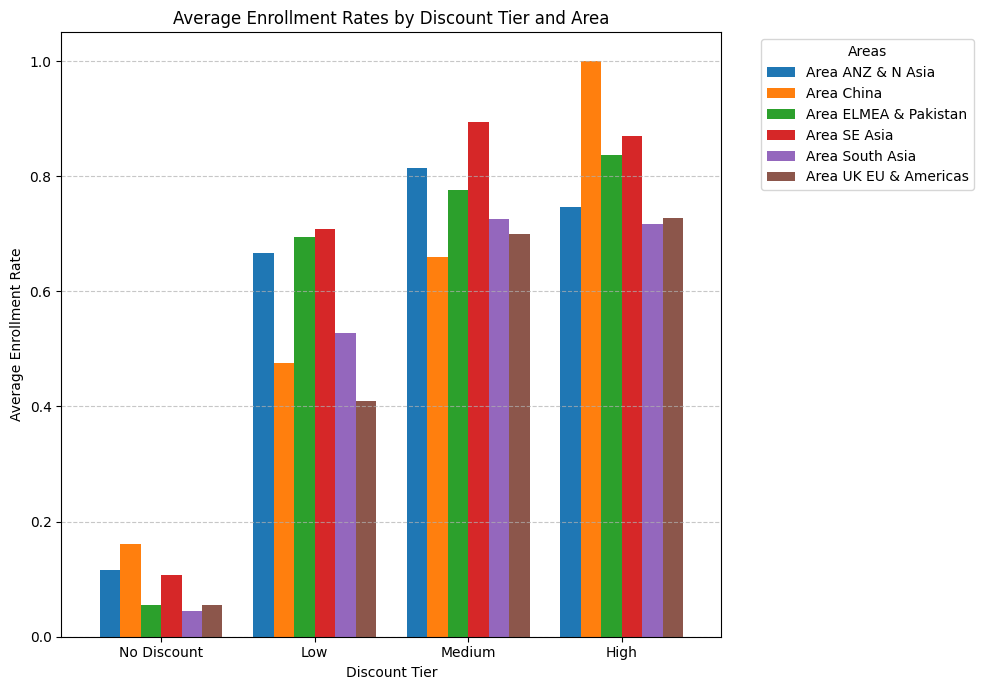

In [ ]:
# Define discount tiers based on actual discount values
bins = [-0.01, 0, 1000, 4000, 9000]  # New bin values based on discount distribution
labels = ['No Discount', 'Low', 'Medium', 'High']
data['Discount_Tier'] = pd.cut(data['Discount'], bins=bins, labels=labels)

# Initialize a DataFrame to store enrollment rates per area and tier
enrollment_summary = pd.DataFrame()

# Calculate and store enrollment rates for each area
for area in data['Area'].unique():
    area_data = data[data['Area'] == area]
    enrollment_rates = area_data.groupby('Discount_Tier')['Enrolled'].mean().reset_index()
    enrollment_rates['Area'] = f'Area {area}'

    # Append to the main DataFrame
    enrollment_summary = pd.concat([enrollment_summary, enrollment_rates], ignore_index=True)

# Export the raw enrollment summary for Tableau
# enrollment_summary.to_csv('enrollment_rates_by_area_and_discount_tier.csv', index=False)

# Pivot the data for easier plotting
pivot_data = enrollment_summary.pivot(index='Discount_Tier', columns='Area', values='Enrolled')

# Create the grouped bar chart
pivot_data.plot(kind='bar', figsize=(10, 7), width=0.8)

# Formatting the plot
plt.title('Average Enrollment Rates by Discount Tier and Area')
plt.ylabel('Average Enrollment Rate')
plt.xlabel('Discount Tier')
plt.xticks(rotation=0)
plt.legend(title='Areas', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



#### 2.5.5.2 Line chart per tier grouped by Area

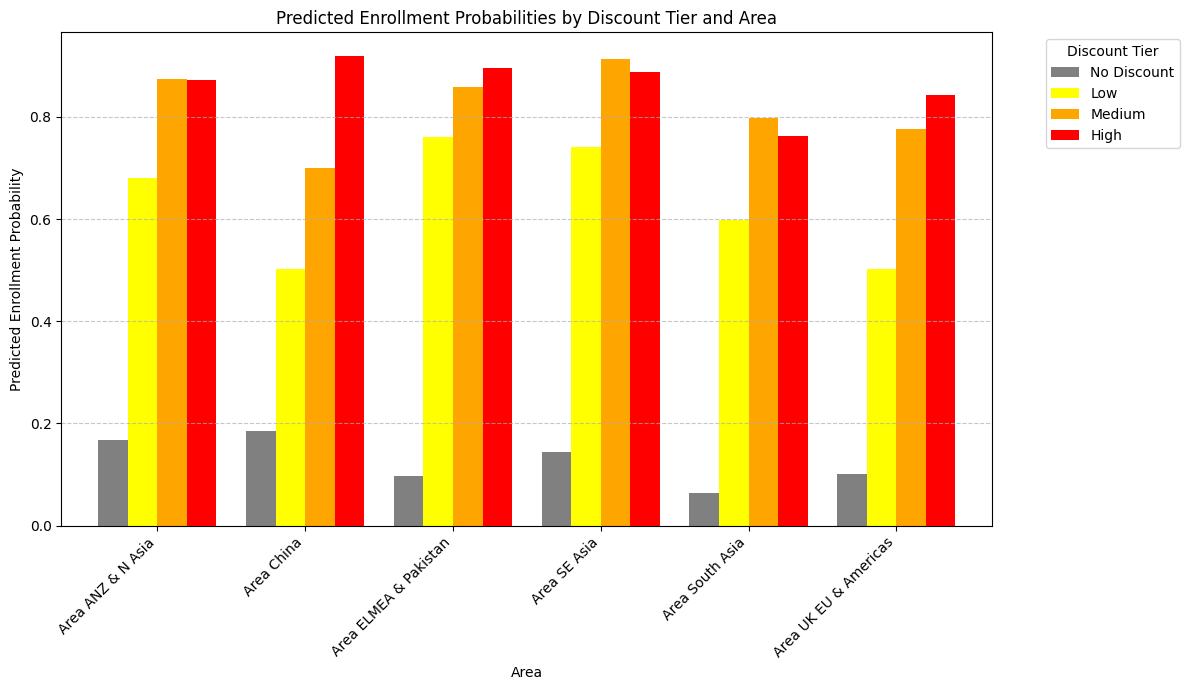

In [ ]:
# Initialize a DataFrame to store predicted enrollment probabilities per area and tier
predicted_enrollment_summary = pd.DataFrame()

# Calculate and store predicted enrollment probabilities for each area using model predictions
for area in data['Area'].unique():
    area_data = data[data['Area'] == area].copy()  # Use .copy() to avoid SettingWithCopyWarning
    clf = area_models[area]  # Get the trained model for the area

    # Extract features for prediction
    X_area = area_data[features]

    # Predict enrollment probabilities
    area_data.loc[:, 'enrollment_probability'] = clf.predict_proba(X_area)[:, 1]

    # Compute average predicted enrollment probability per discount tier
    predicted_rates = area_data.groupby('Discount_Tier', observed=True)['enrollment_probability'].mean().reset_index()
    predicted_rates['Area'] = f'Area {area}'

    # Append to the main DataFrame
    predicted_enrollment_summary = pd.concat([predicted_enrollment_summary, predicted_rates], ignore_index=True)

# Pivot data to reshape it for grouped bars
pivot_data2 = predicted_enrollment_summary.pivot(index='Area', columns='Discount_Tier', values='enrollment_probability')

# Define a custom color palette
custom_palette = {
    'No Discount': 'grey',
    'Low': 'yellow',
    'Medium': 'orange',
    'High': 'red'
}

# Plot as a grouped bar chart
ax = pivot_data2.plot(kind='bar', figsize=(12, 7), width=0.8, color=[custom_palette[col] for col in pivot_data2.columns])

# Formatting the plot
plt.title('Predicted Enrollment Probabilities by Discount Tier and Area')
plt.ylabel('Predicted Enrollment Probability')
plt.xlabel('Area')
plt.xticks(rotation=45, ha="right")
plt.legend(title='Discount Tier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



## Discount Analysis: Key Insights

### Key Takeaways:
- **Diminishing Marginal Returns:**  
  - The analysis reveals that **marginal returns** on enrollment begin to **slow down around the $1,000 to $1,500 range**, with no proportional increase in enrollment beyond the **$1,500/$2,000 mark**.
  - This indicates that larger discounts may not significantly enhance enrollment rates, especially in regions where price sensitivity is lower.
  - To facilitate cross-regional comparisons, discount tiers were **simplified**, enabling clearer insights into discount effectiveness.

- **Regional Variations:**
  - **South Asia and ANZ & N Asia:**  
    - Enrollment probabilities **plateau at lower discount levels**, indicating that further discounts have **limited impact** in these regions. This suggests a **saturation point** where additional financial incentives fail to boost enrollments.
  - **UK, EU & Americas, China, and Pakistan:**  
    - These regions exhibit **stronger responses** to varying discount levels, especially at higher tiers. This highlights the need for **precise and strategic discount allocation** in these markets to maximize enrollment impact.
  - Notably, in **Pakistan (ELMEA & Pakistan)**, discounts play a **crucial role**, underscoring the importance of financial incentives in driving enrollment.

- **Threshold Insights and Scholarship Strategy:**
  - Even at **low-tier discount levels**, enrollment probabilities remain above the threshold, suggesting **latent demand** among price-sensitive applicants.
  - This finding indicates an opportunity to **refine scholarship strategies** by targeting 'on-the-fence' applicants, particularly if augmented with additional data such as **socio-economic status**.

### Granular Agent-Level Analysis:
To complement the regional trends, an **interactive widget** was developed in the Python notebook, enabling users to **search and select specific agents** and observe how **enrollment probabilities evolve** with varying discount levels. This tool:
- Facilitates a **granular analysis** of agent-specific discount effectiveness, offering deeper insights beyond regional averages.
- Supports a **more tailored approach** to discount allocation, optimizing recruitment efforts by agent performance.

### Top and Bottom-Performing Agents:
Building on this analysis, the next section identifies **top and bottom-performing Parent Agents** across regions. This segmentation provides:
- **Actionable insights** into high-performing agents, enabling **refined discount and recruitment strategies**.
- An understanding of **low-performing agents**, guiding **targeted interventions** to enhance their impact or reconsider engagement strategies.
- A strategic foundation for **more effective discount allocation**, maximizing **enrollment impact** and **return on investment**.

### Strategic Implications:
This detailed discount analysis informs **data-driven scholarship strategies**, ensuring that financial aid is **allocated where it has the highest impact**. By balancing **regional trends** with **agent-level insights**, Study Group can optimize **enrollment growth** while minimizing **missed opportunities**.


# 3) Addendum: China

## In-Depth Analysis of China

Study Group requested a **deeper investigation into the Chinese market** to understand the role of **centre reputation** in influencing enrollment likelihood. This addendum explores how **different centres** and their **tuition tiers** impact student decision-making, with a focus on discount sensitivity.

### Objective:
The primary objective was to examine whether certain centres are **more sensitive to discounts** than others, and within each centre, how **tuition levels** (net value after discount) influence enrollment probability. This analysis aims to provide **granular insights** that can enhance **targeted scholarship strategies** in the Chinese market.

### Methodology:
1. **Re-Modeling for Chinese Applicants:**  
   - Focused on Chinese applicants to isolate market-specific dynamics.
   - Identified the **three main centres** driving enrollments: **Durham, Sheffield, and Leeds**.

2. **Tuition Tiering:**  
   - **Net tuition** was tiered into three levels: **Low, Medium, and High**, to investigate discount sensitivity across different pricing bands.
   - This allowed for a more nuanced analysis of how **financial incentives** impact students at different budget levels.

3. **Discount Sensitivity Analysis:**  
   - Modeled the interaction between **centre reputation** and **discount tiers**, examining:
     - Whether a **specific centre** exhibits greater discount sensitivity.
     - Within each centre, whether discounts are **more impactful on high tuition tiers** or **low tuition tiers**.
   - This two-level analysis enables a **comprehensive understanding** of the dynamics between pricing, centre reputation, and student behavior.

### Strategic Relevance:
This approach provides **actionable insights** for Study Group to:
- Optimize **discount allocation** by tailoring strategies for **specific centres** and **tuition tiers**.
- Enhance **competitive positioning** in the Chinese market by aligning scholarship strategies with **student price sensitivity**.
- **Maximize enrollment impact** by strategically leveraging financial incentives where they are most effective.

This deeper investigation into **centre-specific discount sensitivity** offers a **data-driven framework** for refining scholarship policies and strengthening Study Group's market share in China.



 Classification Report for China:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1111
           1       0.80      0.88      0.84       267

    accuracy                           0.93      1378
   macro avg       0.89      0.92      0.90      1378
weighted avg       0.94      0.93      0.94      1378

AUC Score: 0.9740


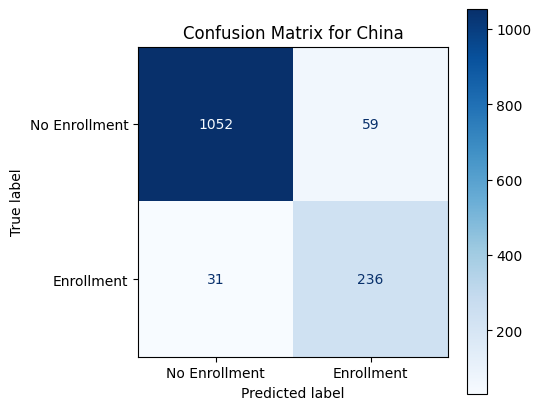

<ipython-input-22-5f28eaa25634>:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')


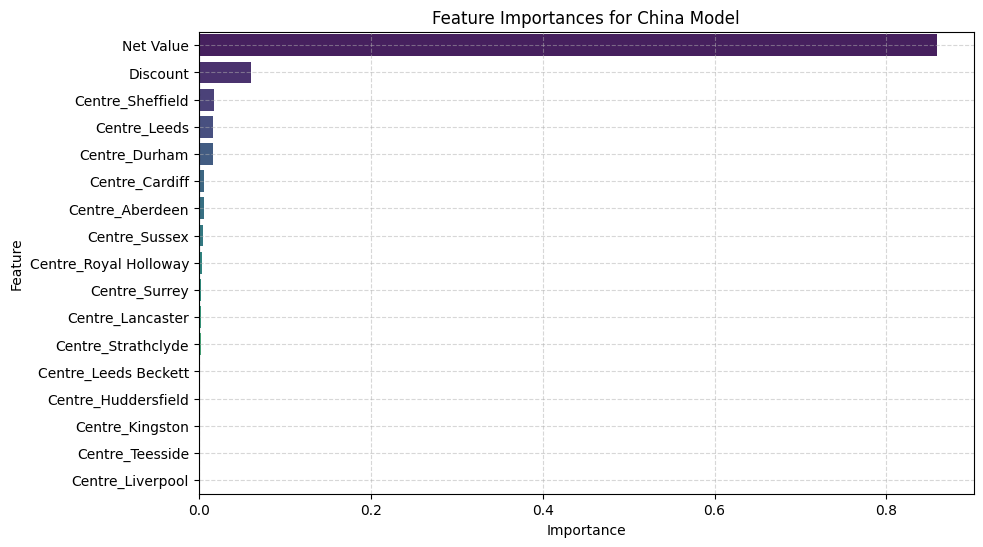

In [ ]:
# Filter Data for China and Select Features
china_data = data[data['Area'] == 'China']

# Features as specified
features = [
    'Discount', 'Net Value',
    'Centre_Aberdeen', 'Centre_Cardiff', 'Centre_Durham', 'Centre_Huddersfield',
    'Centre_Kingston', 'Centre_Lancaster', 'Centre_Leeds',
    'Centre_Leeds Beckett', 'Centre_Liverpool', 'Centre_Royal Holloway',
    'Centre_Sheffield', 'Centre_Strathclyde', 'Centre_Surrey',
    'Centre_Sussex', 'Centre_Teesside'
]

X_china = china_data[features]
y_china = china_data['Enrolled'].astype(int)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_china, y_china, test_size=0.2, random_state=42)

# Train Random Forest Classifier
best_params = {
    'class_weight': {0: 1, 1: 3},
    'max_depth': 15,
    'min_samples_leaf': 1,
    'min_samples_split': 5,
    'n_estimators': 100
}

clf_china = RandomForestClassifier(**best_params, random_state=42)
clf_china.fit(X_train, y_train)

# Evaluate the Model
threshold = 0.4
y_prob = clf_china.predict_proba(X_test)[:, 1]
y_pred_custom = (y_prob >= threshold).astype(int)

print("\n Classification Report for China:")
print(classification_report(y_test, y_pred_custom))
print(f"AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Enrollment", "Enrollment"])

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Confusion Matrix for China')
plt.show()

# Feature Importance Plot
feature_importances = pd.DataFrame({
    'Feature': features,
    'Importance': clf_china.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title('Feature Importances for China Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## Feature Importance and Model Performance: China

### Feature Importance:
- **Net Value** is the most influential factor, underscoring the importance of tuition pricing in enrollment decisions.
- **Discounts** have a secondary impact, while **centre reputation** (e.g., Sheffield, Leeds, Durham) shows minimal influence.

### Model Performance:
- Achieved **93% accuracy** and a high **AUC Score of 0.9740**, indicating strong discriminatory power.
- Balanced performance with **F1-score of 0.84** for enrolled students, effectively managing precision and recall.
- Overall, the model provides **reliable insights** for optimizing discount strategies in the Chinese market.


🔵 Generating PDP for Centre_Durham...
🔵 Generating PDP for Centre_Sheffield...
🔵 Generating PDP for Centre_Leeds...


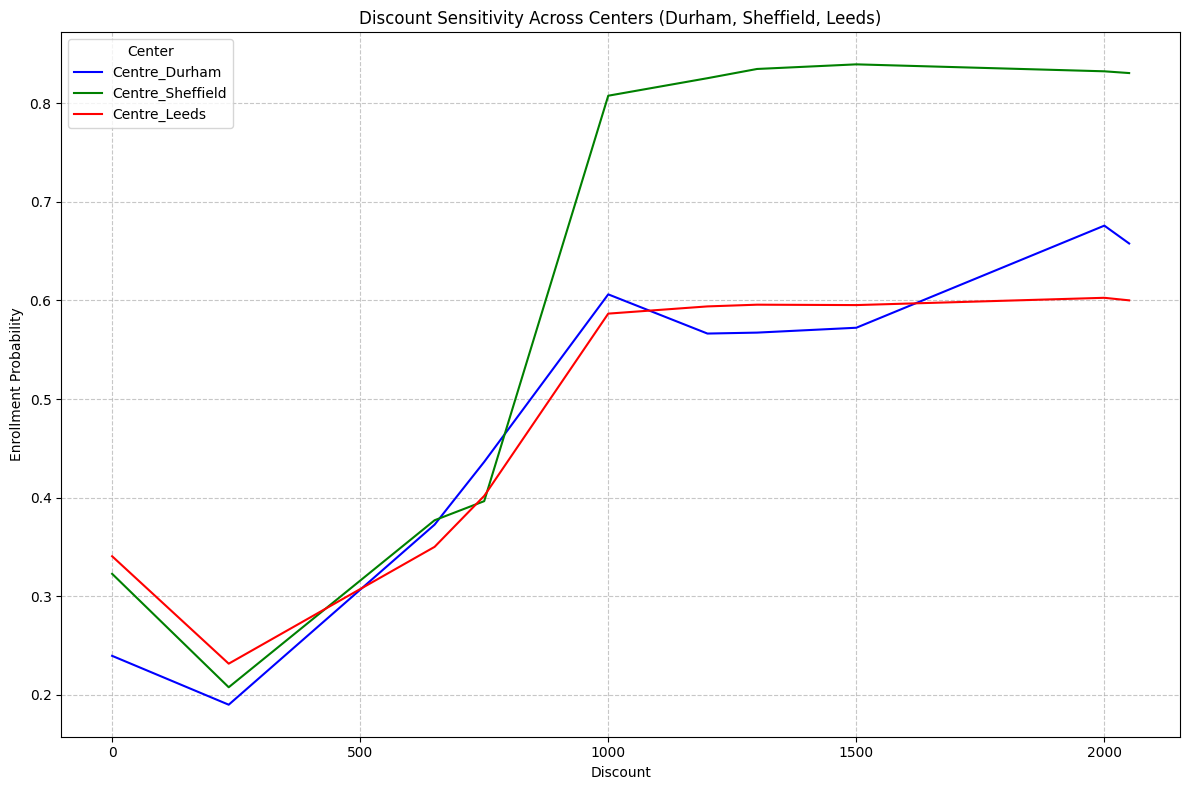

In [ ]:
# Import necessary libraries
from sklearn.inspection import partial_dependence
import numpy as np
import matplotlib.pyplot as plt

# Centers of interest
centers_of_interest = ['Centre_Durham', 'Centre_Sheffield', 'Centre_Leeds']

# Initialize plot
plt.figure(figsize=(12, 8))
colors = ['blue', 'green', 'red']

# Loop through each center and calculate PDP
for i, center in enumerate(centers_of_interest):
    print(f"🔵 Generating PDP for {center}...")

    # Create a copy of the test set
    X_temp = X_test.copy()

    # Set the specific center to 1 and all others to 0
    for c in centers_of_interest:
        X_temp[c] = 1 if c == center else 0

    # Calculate partial dependence for Discount
    pdp_results = partial_dependence(clf_china, X_temp, [X_temp.columns.get_loc('Discount')])
    discount_values = pdp_results['grid_values'][0]
    enrollment_probabilities = pdp_results['average'][0]

    # Plot the PDP
    plt.plot(discount_values, enrollment_probabilities, label=center, color=colors[i])

# Finalize plot
plt.xlabel('Discount')
plt.ylabel('Enrollment Probability')
plt.title('Discount Sensitivity Across Centers (Durham, Sheffield, Leeds)')
plt.legend(title='Center')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Discount Sensitivity Analysis: Top Centers in China

### Key Insights:
1. **Centre_Sheffield:**
   - **Strongest sensitivity to discounts**, with a sharp increase in enrollment probability between **500 and 1000**.
   - **Diminishing returns** occur beyond **1500**, where enrollment probability plateaus.
   - **Recommendation:** Target discounts within the **500-1500 range** to maximize impact, avoiding unnecessary expenditure beyond this threshold.

2. **Centre_Durham:**
   - Moderate discount sensitivity with **steady growth** in enrollment probability up to **2000**.
   - Enrollment stabilizes beyond **2000**, indicating limited effectiveness for higher discounts.
   - **Recommendation:** Implement **moderate discounts (1000-2000)** to optimize enrollment, with potential to test slightly higher discounts to fine-tune the plateau point.

3. **Centre_Leeds:**
   - Exhibits **lower sensitivity** to discounts compared to the other centers.
   - Enrollment probability **increases gradually** and shows minimal change beyond **1000**.
   - **Recommendation:** Focus on **lower-tier discounts (<1000)** to influence enrollment, as larger discounts yield minimal additional benefit.

In [ ]:
# Define Top 3 Centers and Adjusted Net Value Tiers
top_centers = ['Centre_Durham', 'Centre_Sheffield', 'Centre_Leeds']

# Define Adjusted Net Value Tiers
net_value_bins = [16000, 18000, 21000, 24000]
net_value_labels = ['Low', 'Medium', 'High']

# Create a copy of the DataFrame and assign Net Value Tiers
X_china = X_china.copy()  # Copy to avoid SettingWithCopyWarning
X_china['Net_Value_Tier'] = pd.cut(X_china['Net Value'], bins=net_value_bins, labels=net_value_labels, include_lowest=True)

# Initialize a DataFrame to store PDP data for each center and net value tier
pdp_data_list = []

# Loop Through Each Center and Net Value Tier
for center in top_centers:
    for tier in net_value_labels:
        # Copy China data and isolate the specific center and net value tier
        X_filtered = X_china[X_china['Net_Value_Tier'] == tier].copy()  # Use .copy() to avoid SettingWithCopyWarning

        # Drop Net_Value_Tier to avoid feature mismatch error
        X_filtered = X_filtered.drop(columns=['Net_Value_Tier'])

        # Explicitly set the dtype of top_centers columns to int before assigning 0
        X_filtered[top_centers] = X_filtered[top_centers].astype(int)
        X_filtered.loc[:, top_centers] = 0  # Set all centers to 0

        # Activate only the current center
        X_filtered[center] = 1

        # Compute Partial Dependence for Discount
        pdp_results = partial_dependence(clf_china, X_filtered, [X_filtered.columns.get_loc('Discount')])
        discount_levels = pdp_results['grid_values'][0]
        enrollment_probabilities = pdp_results['average'][0]

        # Store PDP data for export
        pdp_data = pd.DataFrame({
            'Discount': discount_levels,
            'Enrollment_Probability': enrollment_probabilities,
            'Center': center,  # Include Center column
            'Net_Value_Tier': tier
        })
        pdp_data_list.append(pdp_data)

# Combine all PDP data into a single DataFrame
pdp_full_data = pd.concat(pdp_data_list, ignore_index=True)


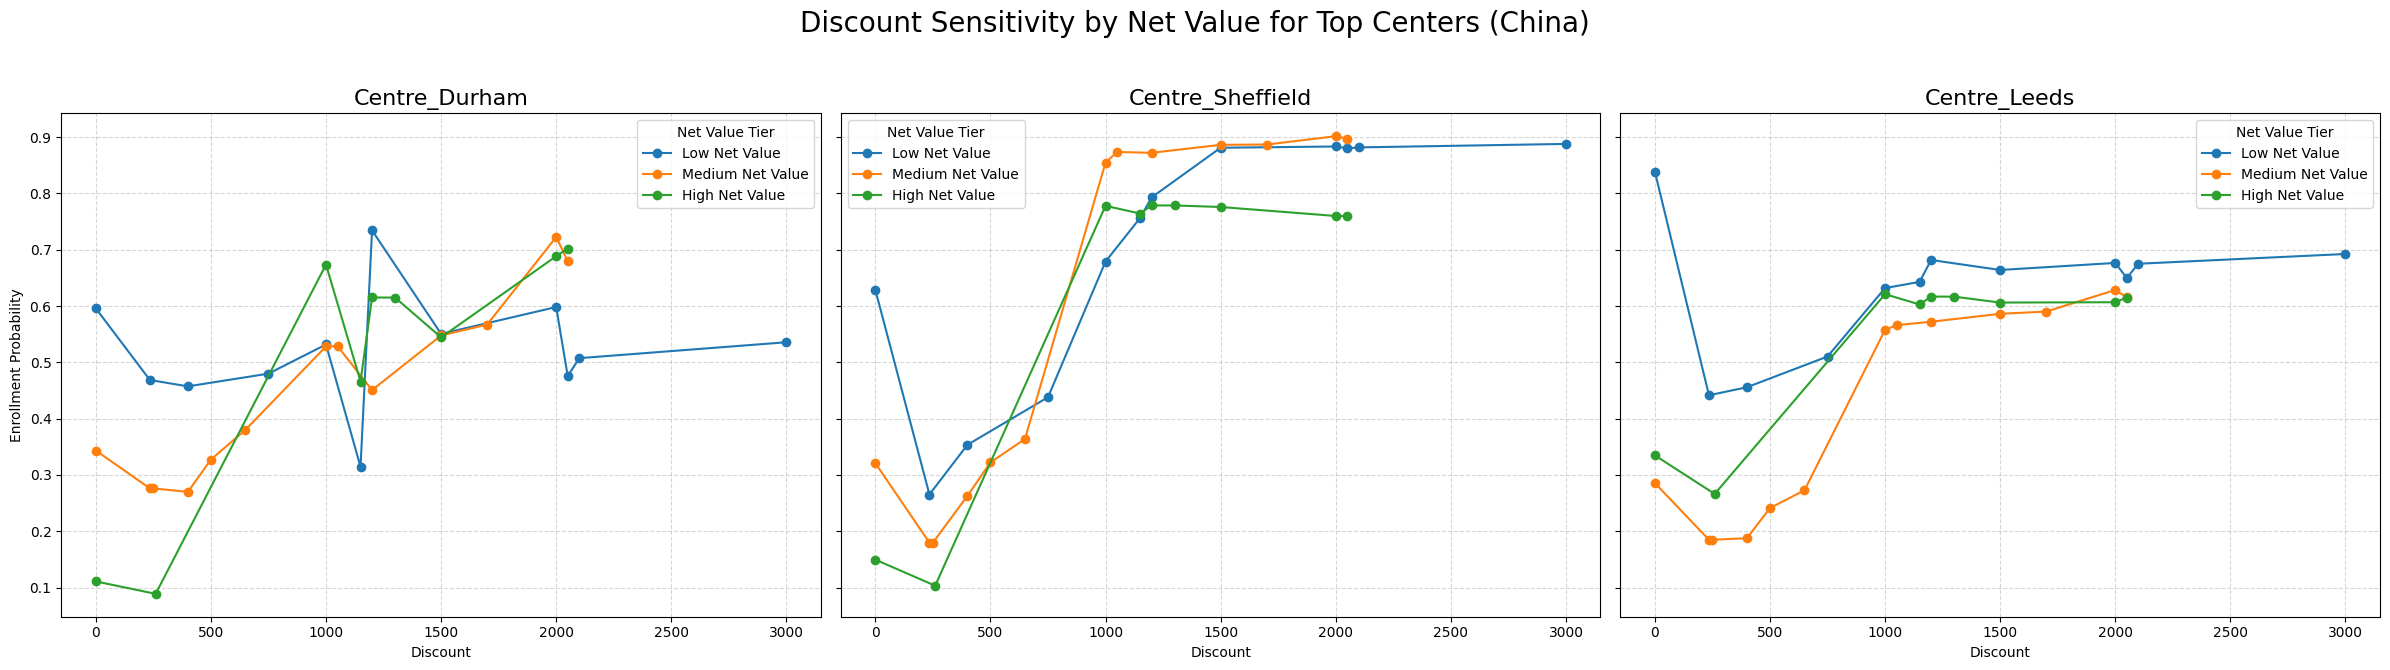

In [ ]:
# Define Top 3 Centers and Adjusted Net Value Tiers
top_centers = ['Centre_Durham', 'Centre_Sheffield', 'Centre_Leeds']
net_value_labels = ['Low', 'Medium', 'High']

# Create Row-Wise Layout for Each Center
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 7), sharey=True)
fig.suptitle('Discount Sensitivity by Net Value for Top Centers (China)', fontsize=20)

for i, center in enumerate(top_centers):
    ax = axes[i]  # Select the subplot for the current center

    # Filter PDP Data for the Current Center
    for tier in net_value_labels:
        pdp_filtered = pdp_full_data[(pdp_full_data['Center'] == center) & (pdp_full_data['Net_Value_Tier'] == tier)]

        # Plot Discount Sensitivity for the Current Net Value Tier
        ax.plot(pdp_filtered['Discount'], pdp_filtered['Enrollment_Probability'],
                 label=f"{tier} Net Value", linestyle='-', marker='o')

    # Plot Settings for the Current Center
    ax.set_title(f'{center}', fontsize=16)
    ax.set_xlabel('Discount')
    if i == 0:
        ax.set_ylabel('Enrollment Probability')  # Only show on the first plot for clarity
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title='Net Value Tier')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit the main title
plt.show()



### Net Value Tier Analysis:
- **Centre_Durham:**
  - **High Net Value** tier is most responsive to discounts, showing sharp increases in enrollment probability.
  - **Low and Medium Net Value** tiers are less sensitive, indicating price inelasticity.
  - **Recommendation:** Concentrate discounts on **high net value students** to enhance enrollment rates.

- **Centre_Sheffield:**
  - **Low and Medium Net Value** tiers demonstrate the **strongest sensitivity**, particularly between **500 and 1500**.
  - **High Net Value** tier shows a plateau early, suggesting limited influence from further discounts.
  - **Recommendation:** Prioritize discounts for **low and medium tiers**, particularly in the **500-1500 range**, for maximum impact.

- **Centre_Leeds:**
  - Discount sensitivity is **relatively uniform** across all tiers, with minor variations.
  - A **gradual increase** is observed, but the impact plateaus early, especially for the **medium tier**.
  - **Recommendation:** Apply **conservative discounts across all tiers**, focusing on **incremental gains** rather than aggressive discounting.
